# ARI vs n_latent
Aggregates ARI scores from `experiments/*/viz` filenames and plots PBMC and BMMC results. Uses the `fivethirtyeight` style from `main.py`.

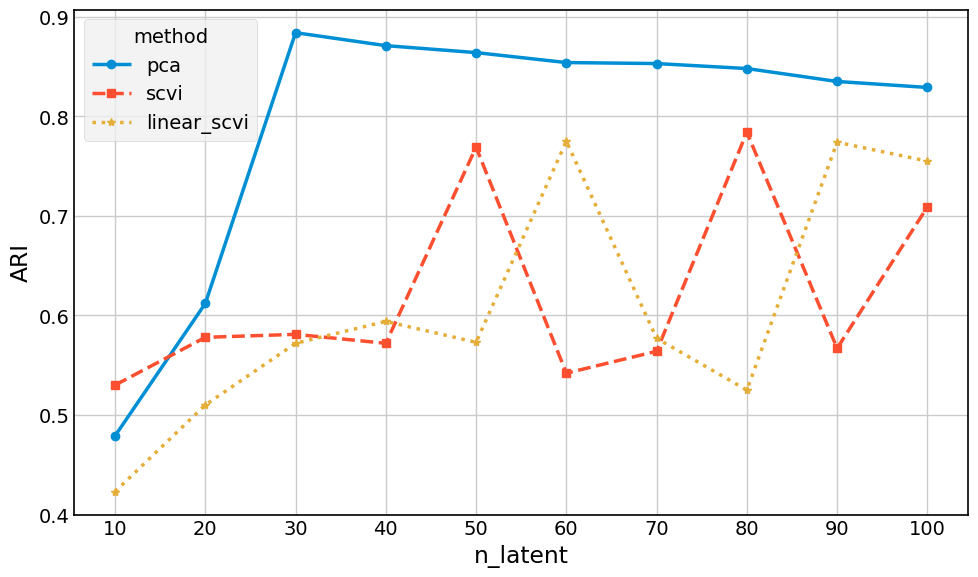

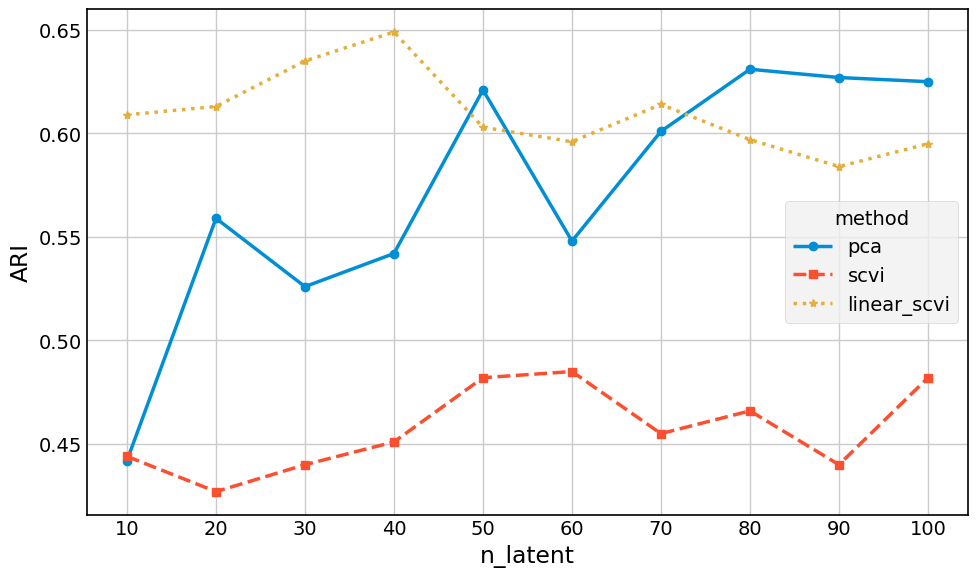

In [14]:
import re
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# Use same plotting theme as in main.py
plt.style.use("fivethirtyeight")

experiments_dir = (
    Path("../experiments").resolve()
    if not Path("experiments").exists()
    else Path("experiments")
)
records = []
# pattern matches folders like: scvi_pbmc_10d_20260422_005414 or linear_scvi_bmmc_50d_...
folder_re = re.compile(
    r"^(?P<method>linear_scvi|scvi|pca)_(?P<dataset>pbmc|bmmc)_(?P<dim>\d+)d_"
)
ari_re = re.compile(r"ari(?P<ari>[0-9]+\.[0-9]+)")

for folder in Path("../experiments").iterdir():
    if not folder.is_dir():
        continue
    m = folder_re.match(folder.name)
    if not m:
        continue
    method = m.group("method")
    dataset = m.group("dataset")
    n_latent = int(m.group("dim"))
    viz_dir = folder / "viz"
    if not viz_dir.exists():
        continue
    for f in viz_dir.iterdir():
        if not f.is_file():
            continue
        # try to extract ari from filename
        mm = ari_re.search(f.name)
        if not mm:
            continue
        ari = float(mm.group("ari"))
        records.append(
            {
                "dataset": dataset,
                "method": method,
                "n_latent": n_latent,
                "ari": ari,
                "file": str(f),
            }
        )

df = pd.DataFrame.from_records(records)
if df.empty:
    print("No ARI records found in experiments/*/viz")
else:
    # ensure numeric sorting
    df["n_latent"] = df["n_latent"].astype(int)
    df = df.sort_values(["method", "dataset", "n_latent"])

    markers = {"pca": "o", "scvi": "s", "linear_scvi": "*"}
    colors = {"pca": "C0", "scvi": "C1", "linear_scvi": "C2"}
    linestyles = {"pca": "-", "scvi": "--", "linear_scvi": ":"}

    for dataset in ["pbmc", "bmmc"]:
        sub = df[df.dataset == dataset]
        fig, ax = plt.subplots(figsize=(10, 6))
        for method in ["pca", "scvi", "linear_scvi"]:
            g = sub[sub.method == method]
            if g.empty:
                continue
            # there should be one value per n_latent; if multiple, plot their mean and scatter individual points lightly
            means = (
                g.groupby("n_latent", as_index=False)["ari"]
                .mean()
                .sort_values("n_latent")
            )
            ax.plot(
                means["n_latent"],
                means["ari"],
                marker=markers.get(method, "o"),
                linestyle=linestyles.get(method, "-"),
                label=method,
                color=colors.get(method),
                linewidth=2.5,
            )
            # plot raw points with low alpha
            ax.scatter(
                g["n_latent"],
                g["ari"],
                alpha=0.45,
                color=colors.get(method),
                marker=markers.get(method, "o"),
            )
        ax.set_xlabel("n_latent")
        ax.set_ylabel("ARI")
        ax.legend(title="method")
        xticks = (
            sorted(sub["n_latent"].unique())
            if not sub.empty
            else sorted(df["n_latent"].unique())
        )
        ax.set_xticks(xticks)
        ax.set_xticklabels(xticks)
        ax.set_facecolor("white")
        fig.patch.set_facecolor("white")

        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_color("black")
            spine.set_linewidth(1.2)

        ax.tick_params(axis="both", colors="black", width=1.2)
        ax.xaxis.label.set_color("black")
        ax.yaxis.label.set_color("black")
        ax.title.set_color("black")
        plt.tight_layout()
        plt.show()